# Cepheid — model & spectrum build (with vmicro variation)

Variant of `cepheid_build.ipynb` that adds a **phase-dependent microturbulence** (ξₛᵢᵣ / `vmicro`) on top of the phase-dependent Teff and log g. The ξ(φ) curve is from Luck (2018, AJ 156, 171) for δ Cep, fit to a 3-term Fourier series (see `xi_micro_deltaCep` below). Range ≈ 2.5–4.0 km/s, RMS residual 0.13 km/s.

Outputs go to separate pickle files so the standard build is left untouched:

- `cepheid_bundles_vmicro.pkl` — a `dict[str, CepheidBundle]` with one entry per emulator variant.
- `cepheid_spectra_vmicro.pkl` — a `dict[str, dict[float, LineSpectra]]` keyed by `(variant, line_center)`.

`CepheidBundle` and `LineSpectra` live in `cepheid_bundles.py` next to this notebook so pickle can resolve them by stable import path.


In [1]:
import sys, os
# sys.path.append('/Users/mjablons/code/spice/src')

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.io import fits
from astropy.table import Table
from scipy import optimize
from scipy.interpolate import interp1d

from spice.spectrum.lazy_zarr_interpolator import (
    IntensityLazyZarrInterpolator, FluxLazyZarrInterpolator,
)
from spice.cepheid_bundles import (
    CepheidBundle, LineSpectra,
    build_bundle, apply_phase_params,
    save_pickle,
)

%matplotlib inline


## Spectrum emulators

We build three families of mesh models:

- `intensity` — `IntensityLazyZarrInterpolator` (11 params: stellar params + per-face `mu`). This is the only emulator we'll feed into the spectrum-synthesis loop, because synthesis needs an intensity function.
- `flux_no_ld` — `FluxLazyZarrInterpolator` with limb-darkening coefficients that disable LD (`[1.0, 1.0, 0., 0.]`).
- `flux_linear_<c>` — `FluxLazyZarrInterpolator` with linear LD law and a few sampled coefficients. Useful for flux-level comparisons; not used for spectrum synthesis here.


In [2]:
LINE_INTERP_PATH = '/g/data/y89/mj8805/fe_regular_nlte_big.zarr'
FLUX_INTERP_PATH = '/g/data/y89/mj8805/fe_nlte_flux_big.zarr/regular_synthesized_spectra.zarr'

INTENSITY_PARAMS = ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]',
                    '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu']
FLUX_PARAMS      = ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]',
                    '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]']

SOLAR_INTENSITY = np.array([5777, 4.44, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
SOLAR_FLUX      = np.array([5777, 4.44, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

intensity_emulator = IntensityLazyZarrInterpolator(
    LINE_INTERP_PATH, params=INTENSITY_PARAMS, solar_parameters=SOLAR_INTENSITY,
    sparse=True, in_memory=False,
)

flux_emulator = FluxLazyZarrInterpolator(
    FLUX_INTERP_PATH, params=FLUX_PARAMS, solar_parameters=SOLAR_FLUX,
    sparse=True, in_memory=False,
)

[spice] zarr loaded in 1.9 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 5.8 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.6 s


## SPIPS3 templates for Delta Cephei


In [3]:
with fits.open('/home/100/mj8805/delta_cep.fits', ignore_missing_simple=True) as hdul:
    hdul.info()
    model_data = Table(hdul[1].data)
    pulsation_data = Table(hdul[2].data)

print(f"Starting radius:  {pulsation_data['R'][0]:.3f} R_sun")
print(f"Starting Teff:    {pulsation_data['Teff'][0]:.1f} K")
print(f"Starting log g:   {pulsation_data['logg'][0]:.3f}")


Filename: /home/100/mj8805/delta_cep.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     354   ()      
  1  DATA          1 BinTableHDU     29   994R x 7C   [D, 52A, E, E, E, E, D]   
  2  MODEL         1 BinTableHDU     75   1000R x 27C   [E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E]   
Starting radius:  41.178 R_sun
Starting Teff:    6562.0 K
Starting log g:   1.883


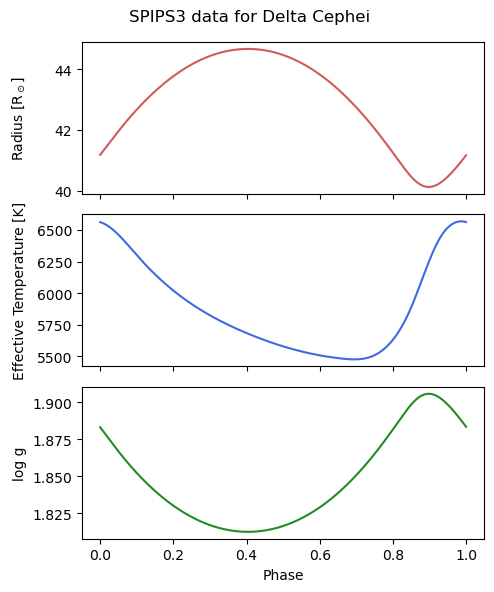

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(5, 6), sharex=True)
fig.suptitle('SPIPS3 data for Delta Cephei')
axs[0].plot(pulsation_data['PHASE'], pulsation_data['R'],    color='indianred')
axs[0].set_ylabel(r'Radius [R$_\odot$]')
axs[1].plot(pulsation_data['PHASE'], pulsation_data['Teff'], color='royalblue')
axs[1].set_ylabel('Effective Temperature [K]')
axs[2].plot(pulsation_data['PHASE'], pulsation_data['logg'], color='forestgreen')
axs[2].set_xlabel('Phase'); axs[2].set_ylabel('log g')
fig.align_ylabels(axs); plt.tight_layout(); plt.show()


## Fourier decomposition of the radius template

`fourier_series_parameters` has shape `(3, n_terms, 2)` — the three rows are the radial / spheroidal / toroidal vector spherical harmonics components. A Cepheid pulsates in a purely radial $\ell=0$, $m=0$ mode, so only the radial row is non-zero.


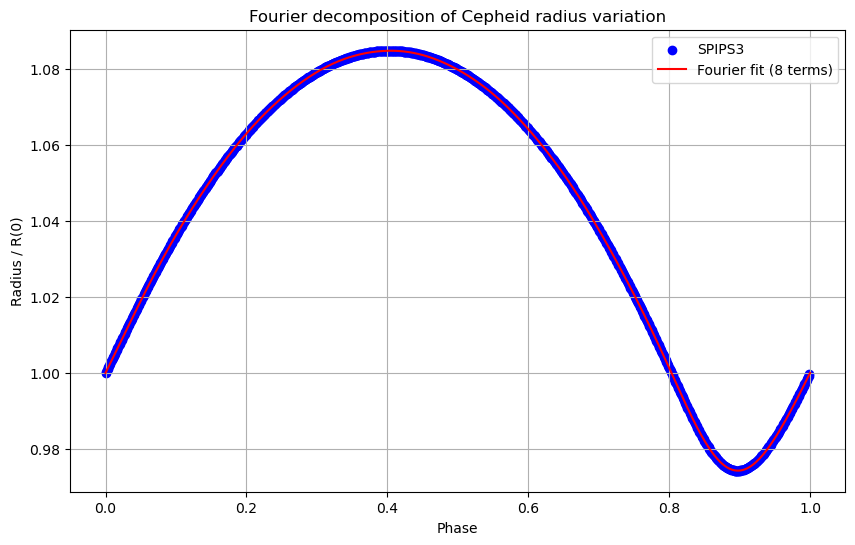

Mean radius (a0): 1.0420
Fourier params shape: (3, 8, 2)


In [5]:
phases_fit = np.array(pulsation_data['PHASE'])
radius_fit_data = np.array(pulsation_data['R'] / pulsation_data['R'][0])
sort_idx = np.argsort(phases_fit)
phases_fit, radius_fit_data = phases_fit[sort_idx], radius_fit_data[sort_idx]

def fourier_series(x, a0, *coeffs):
    n_terms = len(coeffs) // 2
    out = a0
    for i in range(n_terms):
        a_i, b_i = coeffs[2 * i], coeffs[2 * i + 1]
        out = out + a_i * np.cos(2 * np.pi * (i + 1) * x) + b_i * np.sin(2 * np.pi * (i + 1) * x)
    return out

N_TERMS = 8
p0 = [np.mean(radius_fit_data)] + [0.0] * (2 * N_TERMS)
params, _ = optimize.curve_fit(fourier_series, phases_fit, radius_fit_data, p0=p0)
a0, fourier_coeffs = params[0], params[1:]

phase_fine = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
plt.scatter(phases_fit, radius_fit_data, color='blue', label='SPIPS3')
plt.plot(phase_fine, fourier_series(phase_fine, *params), color='red', label=f'Fourier fit ({N_TERMS} terms)')
plt.xlabel('Phase'); plt.ylabel(r'Radius / R(0)'); plt.legend(); plt.grid(True)
plt.title('Fourier decomposition of Cepheid radius variation'); plt.show()

radial_fourier = np.zeros((N_TERMS, 2))
for i in range(N_TERMS):
    a_i, b_i = fourier_coeffs[2 * i], fourier_coeffs[2 * i + 1]
    radial_fourier[i] = [np.sqrt(a_i ** 2 + b_i ** 2), np.arctan2(b_i, a_i)]

fourier_series_parameters = np.stack([
    radial_fourier,                  # radial
    np.zeros_like(radial_fourier),   # spheroidal
    np.zeros_like(radial_fourier),   # toroidal
])

PERIOD = 5.366265401100268
print(f"Mean radius (a0): {a0:.4f}")
print(f"Fourier params shape: {fourier_series_parameters.shape}")


## ξₛᵢᵣ (microturbulence) template for δ Cep

Fourier fit to Luck (2018) Table 3. Phase convention: GCVS (Samus et al. 2017), φ = 0 at maximum light.
Minimum radius near φ ≈ 0.7–0.8. Returns ξ in km/s, range 2.5–4.0, fit RMS 0.13 km/s.


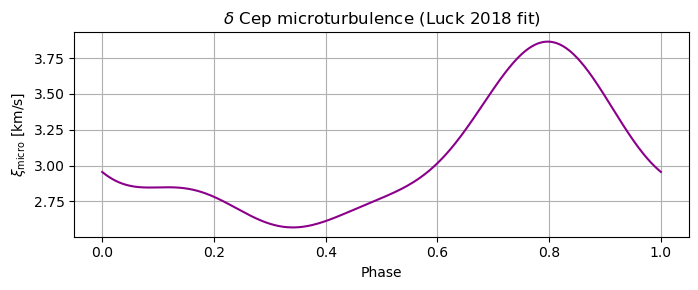

xi range: 2.568 - 3.865 km/s


In [6]:
def xi_micro_deltaCep(phase):
    """ξ (km/s) for δ Cep, fit to Luck 2018 (AJ 156, 171) table 3.
    Phase convention: from the GCVS ephemeris (Samus et al. 2017),
    phase 0 ≈ maximum light. Min radius near phase ~0.7-0.8.
    Range: 2.5–4.0 km/s. RMS fit residual 0.13 km/s."""
    phi = phase % 1.0
    c = [3.046, 0.182, -0.507, -0.182, -0.061, -0.091, 0.040]
    val = c[0]
    for k in range(1, 4):
        val += c[2*k-1]*np.cos(2*np.pi*k*phi) + c[2*k]*np.sin(2*np.pi*k*phi)
    return val

phi_grid = np.linspace(0, 1, 400)
plt.figure(figsize=(7, 3))
plt.plot(phi_grid, xi_micro_deltaCep(phi_grid), color='darkmagenta')
plt.xlabel('Phase'); plt.ylabel(r'$\xi_{\mathrm{micro}}$ [km/s]')
plt.title(r'$\delta$ Cep microturbulence (Luck 2018 fit)')
plt.grid(True); plt.tight_layout(); plt.show()

print(f'xi range: {xi_micro_deltaCep(phi_grid).min():.3f} - {xi_micro_deltaCep(phi_grid).max():.3f} km/s')


## Build the mesh bundles

Stellar parameters (Nardetto et al. 2024; Luck 2018; Takeda 2013; Lemasle et al. 2013; Genovali et al. 2015; Gillet et al. 1999):
- N_mesh=5000, R=43.06 R☉, M=5.26 M☉
- Teff, log g: phase-0 SPIPS3 values
- [Fe/H]=+0.06, vmicro=3.5 km/s, [α/H]=+0.05, [C/Fe]=-0.25, [N/Fe]=+0.4, [O/Fe]=0, [r/Fe]=0, [s/Fe]=+0.15


In [7]:
TIMESERIES = jnp.linspace(0, PERIOD, 100)

stellar_params_dict = {
    'teff':    pulsation_data['Teff'][0],
    'logg':    pulsation_data['logg'][0],
    '[Fe/H]':  0.06,
    'vmicro':  3.5,
}

LD_COEFFS = np.linspace(0.0, 1.0, 20)  # sampled linear-LD coefficients

# (emulator, params, param_names_attr)
BUNDLE_CONFIGS = {
    'intensity':   (intensity_emulator, intensity_emulator.to_parameters(stellar_params_dict), 'stellar_parameter_names'),
    'flux_no_ld':  (flux_emulator, flux_emulator.to_parameters(stellar_params_dict), 'stellar_parameter_names'),
}

print('Will build:', list(BUNDLE_CONFIGS.keys()))

Will build: ['intensity', 'flux_no_ld']


In [8]:
bundles: dict[str, CepheidBundle] = {}
for name, (emul, params, attr) in BUNDLE_CONFIGS.items():
    print(f'Building {name}...')
    bundles[name] = build_bundle(
        emul, params,
        fourier_params=fourier_series_parameters,
        period=PERIOD, timeseries=TIMESERIES,
        param_names_attr=attr,
        desc=f'Evaluating {name}',
    )
print('Done.')


Building intensity...
[spice] IcosphereModel constructed in 4.9 s


[spice] Pulsations evaluated in 11.1 s                                                                                                                                                                  
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                               

Building flux_no_ld...
[spice] IcosphereModel constructed in 0.0 s


[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                                   
[spice] Pulsations evaluated in 0.0 s                                                                                                                                                               

Done.


## Apply phase-dependent Teff, log g, and vmicro

Interpolate the SPIPS3 Teff/log g templates onto our coarser sampling and pull ξ from the analytic Luck (2018) fit, then push all three into every bundle's snapshots in one loop.


In [9]:
phase_data = np.asarray(pulsation_data['PHASE'])
sort_idx   = np.argsort(phase_data)
phase_sorted = phase_data[sort_idx]
teff_sorted  = np.asarray(pulsation_data['Teff'])[sort_idx]
logg_sorted  = np.asarray(pulsation_data['logg'])[sort_idx]

teff_interp = interp1d(phase_sorted, teff_sorted, kind='cubic', bounds_error=False,
                       fill_value=(teff_sorted[-1], teff_sorted[0]), assume_sorted=True)
logg_interp = interp1d(phase_sorted, logg_sorted, kind='cubic', bounds_error=False,
                       fill_value=(logg_sorted[-1], logg_sorted[0]), assume_sorted=True)

teff_at   = lambda p: float(teff_interp(p % 1.0))
logg_at   = lambda p: float(logg_interp(p % 1.0))
vmicro_at = lambda p: float(xi_micro_deltaCep(p))

phases_per_snapshot = [(t % PERIOD) / PERIOD for t in TIMESERIES]

# Param indices: 0 = teff, 1 = logg, 3 = vmicro (same ordering for intensity and flux schemes).
for name, bundle in bundles.items():
    bundles[name] = apply_phase_params(
        bundle, phases_per_snapshot,
        modifiers=[(0, teff_at), (1, logg_at), (3, vmicro_at)],
    )
print('Phase-dependent Teff/logg/vmicro applied.')


Phase-dependent Teff/logg/vmicro applied.


In [10]:
save_pickle(bundles, 'cepheid_bundles_vmicro.pkl')
print('Saved cepheid_bundles_vmicro.pkl with bundles:', list(bundles.keys()))


Saved cepheid_bundles_vmicro.pkl with bundles: ['intensity', 'flux_no_ld']


## Synthesise spectra (5000–5020 Å)

One wavelength window per variant, evaluated at every phase snapshot. Variants:

- `with_ld` — `intensity_emulator.intensity` evaluated at each face's projected `mu` (intensity-grid LD).
- `flux_no_ld`, `flux_linear_<c>` — `FluxLazyZarrInterpolator.intensity` on the matching mesh. LD comes from the linear law plus the emulator's `limb_darkening_coeffs`. Note: despite its legacy name, `flux_no_ld` was configured with `[1.0, 1.0, 0, 0]` — i.e., maximum-strength linear LD (u=1.0).

Synthesis is the slow step.

In [11]:
from spice.spectrum import simulate_observed_flux

def simulate_line_spectra(
    snapshots: list,
    template_snapshot,
    intensity_fn,
    line_centers,
    *,
    line_width: float = 2.0,
    steps: int = 500,
    desc: str = "lines",
    ld_coeffs: jnp.ndarray | None = None,
) -> dict[float, LineSpectra]:
    """Synthesise spectra for each line center across all snapshots + a t=0 template."""
    out: dict[float, LineSpectra] = {}
    for lc in tqdm(line_centers, desc=desc):
        wl = jnp.linspace(lc - line_width, lc + line_width, steps)
        log_wl = jnp.log10(wl)
        if ld_coeffs is not None:
            per_snapshot = [
                simulate_observed_flux(intensity_fn, m, log_wl, ld_coeffs=ld_coeffs)
                for m in tqdm(snapshots, desc=f"line {lc:.2f}", leave=False)
            ]
            template = simulate_observed_flux(intensity_fn, template_snapshot, log_wl, ld_coeffs=ld_coeffs)
        else:
            per_snapshot = [
                simulate_observed_flux(intensity_fn, m, log_wl)
                for m in tqdm(snapshots, desc=f"line {lc:.2f}", leave=False)
            ]
            template = simulate_observed_flux(intensity_fn, template_snapshot, log_wl)
        out[float(lc)] = LineSpectra(wavelengths=wl, spectra=per_snapshot, template=template)
    return out

In [12]:
WL_MIN, WL_MAX = 5000.0, 5020.0
WL_STEPS = 2000

# Each variant pairs an intensity function with the bundle whose parameter
# scheme matches that emulator. The intensity bundle uses the 11-param scheme
# (with mu); the flux bundles use the 10-param scheme and the LD law baked
# into FluxLazyZarrInterpolator.intensity().
SPECTRUM_VARIANTS = [
    ('with_ld',    intensity_emulator.intensity, bundles['intensity'], None),
]
for c in LD_COEFFS:
    name = f'flux_linear_{c:.3f}'
    SPECTRUM_VARIANTS.append((name, flux_emulator.intensity, bundles['flux_no_ld'], jnp.array([c, 0.0, 0., 0.])))

line_center = 0.5 * (WL_MIN + WL_MAX)
line_width = 0.5 * (WL_MAX - WL_MIN)

spectra_dataset: dict[str, dict[float, LineSpectra]] = {}
for name, intensity_fn, bundle, ld_coeffs in SPECTRUM_VARIANTS:
    print(f'Synthesising {name} spectra...')
    if ld_coeffs is not None:
        spectra_dataset[name] = simulate_line_spectra(
            bundle.snapshots, bundle.snapshots[0], intensity_fn, (line_center,),
            line_width=line_width, steps=WL_STEPS,
            ld_coeffs=ld_coeffs,
        )
    else:
        spectra_dataset[name] = simulate_line_spectra(
            bundle.snapshots, bundle.snapshots[0], intensity_fn, (line_center,),
            line_width=line_width, steps=WL_STEPS,
        )

Synthesising with_ld spectra...


lines:   0%|                                                                                                                                                                      | 0/1 [00:00<?, ?it/s]/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
lines: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [03:50<00:00, 230.72s/it]


Synthesising flux_linear_0.000 spectra...


lines: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:27<00:00, 87.28s/it]


Synthesising flux_linear_0.053 spectra...


...

lines: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:30<00:00, 90.79s/it]


Synthesising flux_linear_0.947 spectra...


lines: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:25<00:00, 85.22s/it]


Synthesising flux_linear_1.000 spectra...


lines: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:11<00:00, 71.36s/it]


In [13]:
save_pickle(spectra_dataset, 'cepheid_spectra_vmicro.pkl')
print('Saved cepheid_spectra_vmicro.pkl with variants:', list(spectra_dataset.keys()))


Saved cepheid_spectra_vmicro.pkl with variants: ['with_ld', 'flux_linear_0.000', 'flux_linear_0.053', 'flux_linear_0.105', 'flux_linear_0.158', 'flux_linear_0.211', 'flux_linear_0.263', 'flux_linear_0.316', 'flux_linear_0.368', 'flux_linear_0.421', 'flux_linear_0.474', 'flux_linear_0.526', 'flux_linear_0.579', 'flux_linear_0.632', 'flux_linear_0.684', 'flux_linear_0.737', 'flux_linear_0.789', 'flux_linear_0.842', 'flux_linear_0.895', 'flux_linear_0.947', 'flux_linear_1.000']


Build complete. Move on to `cepheid_analysis.ipynb`.
